In [1]:
#import ROOT
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from scipy.interpolate import interp1d

In [2]:
# Telescope positions

In [3]:
# (North, West)

old_T1_pos = (-23.7, 37.6)
T1_pos = (-8.61, -135.48)
T2_pos = (-47.7, -44.1)
T3_pos = (60.1, -29.4)
T4_pos = (11.3, 35.9)

In [4]:
t = np.linspace(0, 1, 1000)

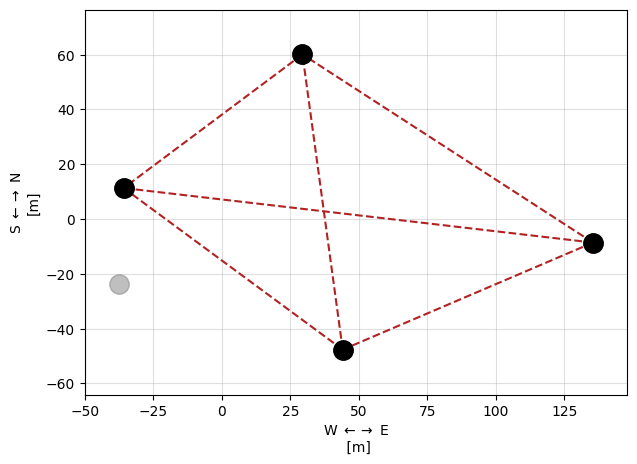

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

plt.plot(-T1_pos[1] * (1-t) + -T2_pos[1] * t, T1_pos[0] * (1-t) + T2_pos[0] * t, ls='--', c='firebrick')
plt.plot(-T1_pos[1] * (1-t) + -T3_pos[1] * t, T1_pos[0] * (1-t) + T3_pos[0] * t, ls='--', c='firebrick')
plt.plot(-T1_pos[1] * (1-t) + -T4_pos[1] * t, T1_pos[0] * (1-t) + T4_pos[0] * t, ls='--', c='firebrick')
plt.plot(-T2_pos[1] * (1-t) + -T3_pos[1] * t, T2_pos[0] * (1-t) + T3_pos[0] * t, ls='--', c='firebrick')
plt.plot(-T2_pos[1] * (1-t) + -T4_pos[1] * t, T2_pos[0] * (1-t) + T4_pos[0] * t, ls='--', c='firebrick')
plt.plot(-T3_pos[1] * (1-t) + -T4_pos[1] * t, T3_pos[0] * (1-t) + T4_pos[0] * t, ls='--', c='firebrick')

for position in (T1_pos, T2_pos, T3_pos, T4_pos):
    plt.plot(-position[1], position[0], marker='o', c='black', ms=14)
    
plt.plot(-old_T1_pos[1], old_T1_pos[0], marker='o', c='grey', ms=14, alpha=0.5)
                
plt.grid(alpha=0.4)
plt.axis('equal')

plt.xlabel(r'W $\leftarrow\rightarrow$ E' + '\n [m]')
plt.ylabel(r'S $\leftarrow\rightarrow$ N' + '\n[m]')

diff = 11
xlims = ax.xaxis.axes.get_xlim()
plt.xlim(xlims[0] - diff, xlims[1] + diff)
ylims = ax.xaxis.axes.get_ylim()
plt.ylim(ylims[0] - diff, ylims[1] + diff)

plt.show()

In [6]:
def get_dist(T, other_T):
    
    sq = (T[0] - other_T[0]) ** 2 + (T[1] - other_T[1]) ** 2
    
    return np.sqrt(sq)

In [7]:
(get_dist(T1_pos, T2_pos),
get_dist(T1_pos, T3_pos),
get_dist(T1_pos, T4_pos),
get_dist(T2_pos, T3_pos),
get_dist(T2_pos, T4_pos),
get_dist(T3_pos, T4_pos))

(99.38980078458755,
 126.38841125672874,
 172.5326418391604,
 108.79765622475514,
 99.40321926376429,
 81.52012021580929)

In [8]:
# Upper limits from previous searches

In [9]:
def gamma_from_beta(b):
    return (1 - b**2)**-0.5
def beta_from_gamma(g):
    return (1 - g**-2)**0.5

In [10]:
betas = np.logspace(-5, 0, 10000)
gammas = np.logspace(0, 12, 10000)

In [11]:
antares_b = np.ones_like(betas) * np.nan

antares_b[(0.55 <= betas) & (betas < 0.5945)] = 8.0e-18
antares_b[(0.5945 <= betas) & (betas < 0.6390)] = 5.8e-18
antares_b[(0.6390 <= betas) & (betas < 0.6835)] = 3.0e-18
antares_b[(0.6835 <= betas) & (betas < 0.7280)] = 3.2e-18
antares_b[(0.7280 <= betas) & (betas < 0.7725)] = 3.1e-18
antares_b[(0.7725 <= betas) & (betas < 0.8170)] = 3.4e-18
antares_b[(0.8170 <= betas) & (betas < 0.8615)] = 2.6e-18
antares_b[(0.8615 <= betas) & (betas < 0.9060)] = 1.1e-18
antares_b[(0.9060 <= betas) & (betas < 0.9505)] = 6.7e-19
antares_b[(0.9505 <= betas) & (betas <= 0.9950)] = 5.6e-19

In [12]:
antares_g = np.ones_like(gammas) * np.nan

antares_g[(gamma_from_beta(0.55) <= gammas) & (gammas < gamma_from_beta(0.5945))] = 8.0e-18
antares_g[(gamma_from_beta(0.5945) <= gammas) & (gammas < gamma_from_beta(0.6390))] = 5.8e-18
antares_g[(gamma_from_beta(0.6390) <= gammas) & (gammas < gamma_from_beta(0.6835))] = 3.0e-18
antares_g[(gamma_from_beta(0.6835) <= gammas) & (gammas < gamma_from_beta(0.7280))] = 3.2e-18
antares_g[(gamma_from_beta(0.7280) <= gammas) & (gammas < gamma_from_beta(0.7725))] = 3.1e-18
antares_g[(gamma_from_beta(0.7725) <= gammas) & (gammas < gamma_from_beta(0.8170))] = 3.4e-18
antares_g[(gamma_from_beta(0.8170) <= gammas) & (gammas < gamma_from_beta(0.8615))] = 2.6e-18
antares_g[(gamma_from_beta(0.8615) <= gammas) & (gammas < gamma_from_beta(0.9060))] = 1.1e-18
antares_g[(gamma_from_beta(0.9060) <= gammas) & (gammas < gamma_from_beta(0.9505))] = 6.7e-19
antares_g[(gamma_from_beta(0.9505) <= gammas) & (gammas <= gamma_from_beta(0.9950))] = 5.6e-19

In [13]:
amanda_up_b_interp = [0.76, 0.8, 0.9, 1]
amanda_up_flux_interp = [8.8e-16, 6.7e-17, 4.3e-17, 3.8e-17]
amanda_up_interp = interp1d(np.log10(amanda_up_b_interp), np.log10(amanda_up_flux_interp))

amanda_down_b_interp = [0.8, 0.9, 1]
amanda_down_flux_interp = [1.7e-15, 4.2e-16, 2.9e-16]
amanda_down_interp = interp1d(np.log10(amanda_down_b_interp), np.log10(amanda_down_flux_interp))

In [14]:
amanda_up_b = np.ones_like(betas) * np.nan
amanda_up_b[(0.76 <= betas) & (betas <= 1)] = 10**amanda_up_interp(np.log10(betas[(0.76 <= betas) & (betas <= 1)]))

amanda_down_b = np.ones_like(betas) * np.nan
amanda_down_b[(0.8 <= betas) & (betas <= 1)] = 10**amanda_down_interp(np.log10(betas[(0.8 <= betas) & (betas <= 1)]))

In [15]:
amanda_up_g = np.ones_like(gammas) * np.nan
amanda_up_g[(gamma_from_beta(0.76) <= gammas) & (gammas <= 1e3)] = 10**amanda_up_interp(np.log10(
    beta_from_gamma(gammas[(gamma_from_beta(0.76) <= gammas) & (gammas <= 1e3)])))

amanda_down_g = np.ones_like(gammas) * np.nan
amanda_down_g[(gamma_from_beta(0.8) <= gammas) & (gammas <= 1e3)] = 10**amanda_down_interp(np.log10(
    beta_from_gamma(gammas[(gamma_from_beta(0.8) <= gammas) & (gammas <= 1e3)])))

In [16]:
bdunt_b_interp = [0.8, 0.9, 1]
bdunt_flux_interp = [1.83e-16, 6.5e-17, 4.6e-17]
bdunt_interp = interp1d(np.log10(bdunt_b_interp), np.log10(bdunt_flux_interp))

In [17]:
bdunt_b = np.ones_like(betas) * np.nan
bdunt_b[(0.8 <= betas) & (betas <= 1)] = 10**bdunt_interp(np.log10(betas[(0.8 <= betas) & (betas <= 1)]))

In [18]:
bdunt_g = np.ones_like(gammas) * np.nan
bdunt_g[(gamma_from_beta(0.8) <= gammas) & (gammas <= 1e3)] = 10**bdunt_interp(np.log10(
    beta_from_gamma(gammas[(gamma_from_beta(0.8) <= gammas) & (gammas <= 1e3)])))

In [19]:
hess_g = np.ones_like(gammas) * np.nan

hess_g[(10**4.9 <= gammas) & (gammas < 10**5.1)] = 4.5e-14

In [20]:
# icecube_old_b = np.ones_like(betas) * np.nan
# icecube_old_b[(0.51 <= betas) & (betas <= 0.87)] = 1.55e-18

In [21]:
# icecube_old_g = np.ones_like(gammas) * np.nan
# icecube_old_g[(gamma_from_beta(0.51) <= gammas) & (gammas <= gamma_from_beta(0.87))] = 1.55e-18

In [22]:
icecube_b = np.ones_like(betas) * np.nan
icecube_b[(0.51 <= betas) & (betas < 0.75)] = 1.55e-18
icecube_b[(0.75 <= betas) & (betas <= 0.995)] = 2.0e-19

In [23]:
icecube_g = np.ones_like(gammas) * np.nan
icecube_g[(gamma_from_beta(0.51) <= gammas) & (gammas < gamma_from_beta(0.75))] = 1.55e-18
icecube_g[(gamma_from_beta(0.75) <= gammas) & (gammas <= gamma_from_beta(0.995))] = 2.0e-19

In [24]:
macro_1_b_interp = [4e-5, 1e-4]
macro_1_flux_interp = [3.1e-16, 2.1e-16]
macro_1_interp = interp1d(np.log10(macro_1_b_interp), np.log10(macro_1_flux_interp))

macro_2_b_interp = [1.1e-4, 2.6e-4]
macro_2_flux_interp = [1.3e-16, 1.5e-16]
macro_2_interp = interp1d(np.log10(macro_2_b_interp), np.log10(macro_2_flux_interp))

macro_3_b_interp = [4.1e-3, 5e-3]
macro_3_flux_interp = [1.6e-16, 1.66e-16]
macro_3_interp = interp1d(np.log10(macro_3_b_interp), np.log10(macro_3_flux_interp))

macro_4_b_interp = [5e-3, 0.1]
macro_4_flux_interp = [1.8e-16, 1.5e-16]
macro_4_interp = interp1d(np.log10(macro_4_b_interp), np.log10(macro_4_flux_interp))

In [25]:
macro_b = np.ones_like(betas) * np.nan

macro_b[(4e-5 <= betas) & (betas < 1.0e-4)] = 10**macro_1_interp(np.log10(betas[(4e-5 <= betas) & (betas < 1.0e-4)]))
macro_b[(1e-4 <= betas) & (betas < 1.1e-4)] = 1.6e-16
macro_b[(1.1e-4 <= betas) & (betas < 2.6e-4)] = 10**macro_2_interp(np.log10(betas[(1.1e-4 <= betas) & (betas < 2.6e-4)]))
macro_b[(2.6e-4 <= betas) & (betas < 1.2e-3)] = 1.6e-16
macro_b[(1.2e-3 <= betas) & (betas < 1.9e-3)] = 1.4e-16
macro_b[(1.9e-3 <= betas) & (betas < 3.0e-3)] = 1.3e-16
macro_b[(3.0e-3 <= betas) & (betas < 4.1e-3)] = 1.6e-16
macro_b[(4.1e-3 <= betas) & (betas < 5e-3)] = 10**macro_3_interp(np.log10(betas[(4.1e-3 <= betas) & (betas < 5e-3)]))
macro_b[(5e-3 <= betas) & (betas < 0.1)] = 10**macro_4_interp(np.log10(betas[(5e-3 <= betas) & (betas < 0.1)]))
macro_b[(0.1 <= betas) & (betas <= 1)] = 1.4e-16

In [26]:
macro_g = np.ones_like(gammas) * np.nan

macro_g[(gamma_from_beta(5e-3) <= gammas) & (gammas < gamma_from_beta(0.1))] = 10**macro_4_interp(np.log10(
    beta_from_gamma(gammas[(gamma_from_beta(5e-3) <= gammas) & (gammas < gamma_from_beta(0.1))])))
macro_g[(gamma_from_beta(0.1) <= gammas) & (gammas <= gamma_from_beta(0.995))] = 1.4e-16

In [27]:
auger_g_interp = [1e8, 1e9, 1e10, 1e11, 1e12]
auger_flux_interp = [8.43e-18, 1.03e-19, 2.18e-20, 3.12e-21, 2.51e-21]
auger_interp = interp1d(np.log10(auger_g_interp), np.log10(auger_flux_interp))

In [28]:
auger_g = np.ones_like(gammas) * np.nan

auger_g[(1e8 <= gammas) & (gammas <= 1e12)] = 10**auger_interp(np.log10(gammas[(1e8 <= gammas) & (gammas <= 1e12)]))

In [29]:
rice_g_interp = [1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
rice_flux_interp = [2.2e-18, 1.9e-19, 2.8e-19, 6.2e-19, 6e-19, 9.5e-19]
rice_interp = interp1d(np.log10(rice_g_interp), np.log10(rice_flux_interp))

In [30]:
rice_g = np.ones_like(gammas) * np.nan

rice_g[(1e7 <= gammas) & (gammas <= 1e12)] = 10**rice_interp(np.log10(gammas[(1e7 <= gammas) & (gammas <= 1e12)]))

In [31]:
slim_m_b = np.ones_like(betas) * np.nan
slim_m_b[(4e-5 <= betas) & (betas <= 1)] = 1.3e-15

slim_M_b = np.ones_like(betas) * np.nan
slim_M_b[(4e-5 <= betas) & (betas <= 1)] = 6.5e-16

In [32]:
slim_m_g = np.ones_like(gammas) * np.nan
slim_m_g[(beta_from_gamma(4e-5) <= gammas) & (beta_from_gamma(gammas) <= 0.995)] = 1.3e-15

slim_M_g = np.ones_like(betas) * np.nan
slim_M_g[(beta_from_gamma(4e-5) <= gammas) & (beta_from_gamma(gammas) <= 0.995)] = 6.5e-16

In [33]:
superk_b_interp = [1e-5, 1e-4, 1e-3]
superk_flux_interp = [6.3e-28, 6.3e-26, 6.3e-24]
superk_interp = interp1d(np.log10(superk_b_interp), np.log10(superk_flux_interp))

In [34]:
superk_b = np.ones_like(betas) * np.nan

superk_b[(1e-5 <= betas) & (betas <= 1e-3)] = 10**superk_interp(np.log10(betas[(1e-5 <= betas) & (betas <= 1e-3)]))

In [35]:
parker_bound_b = np.ones_like(betas) * 1e-15
parker_bound_g = np.ones_like(gammas) * 1e-15

In [36]:
clrs = ['black', 'darkred', 'red', 'darkorange', 'gold', 'lime', 'forestgreen', 'darkcyan', 'deepskyblue', 'royalblue', 
        'blueviolet', 'fuchsia']

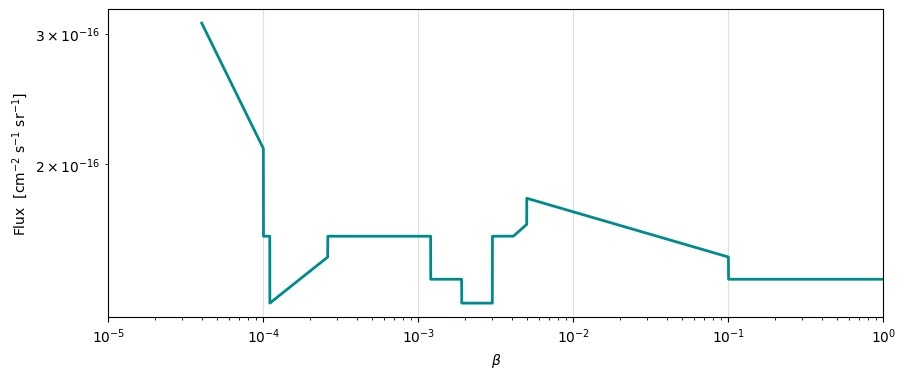

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))


plt.plot(betas, macro_b, c=clrs[7], lw=2)

plt.grid(alpha=0.4)
plt.xlim(np.min(betas), np.max(betas))
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\beta$')
plt.ylabel(r'Flux  [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')

plt.show()

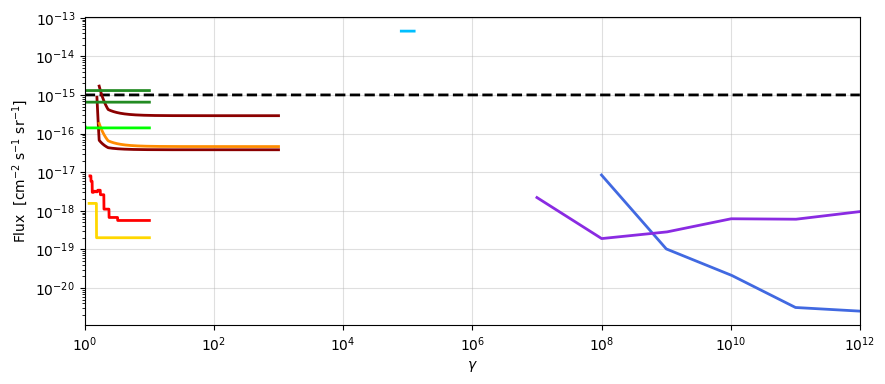

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(gammas, parker_bound_g, ls='--', c=clrs[0], lw=2)
plt.plot(gammas, amanda_up_g, c=clrs[1], lw=2)
plt.plot(gammas, amanda_down_g, c=clrs[1], lw=2)
plt.plot(gammas, antares_g, c=clrs[2], lw=2)
plt.plot(gammas, bdunt_g, c=clrs[3], lw=2)
plt.plot(gammas, icecube_g, c=clrs[4], lw=2)
plt.plot(gammas, macro_g, c=clrs[5], lw=2)
plt.plot(gammas, slim_m_g, c=clrs[6], lw=2)
plt.plot(gammas, slim_M_g, c=clrs[6], lw=2)
plt.plot(gammas, hess_g, c=clrs[8], lw=2)
plt.plot(gammas, auger_g, c=clrs[9], lw=2)
plt.plot(gammas, rice_g, c=clrs[10], lw=2)

plt.grid(alpha=0.4)
plt.xlim(np.min(gammas), np.max(gammas))
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\gamma$')
plt.ylabel(r'Flux  [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')

plt.show()

In [39]:
# grid = plt.GridSpec(1, 3, wspace=0.1, hspace=0.1)

# plt.figure(figsize=(13, 4.5))

# plt.subplot(grid[:, :2])

# plt.plot(betas, parker_bound_b, ls='--', c=clrs[0], lw=2, label='Parker bound')
# plt.plot(betas, amanda_up_b, c=clrs[1], lw=2, label='AMANDA-II')
# # plt.plot(betas, amanda_down_b, c=clrs[1], lw=2)
# plt.plot(betas, antares_b, c=clrs[2], lw=2, label='ANTARES')
# plt.plot(betas, bdunt_b, c=clrs[3], lw=2, label='BDUNT')
# plt.plot(betas, icecube_b, c=clrs[4], lw=2, label='IceCube')
# plt.plot(betas, macro_b, c=clrs[5], lw=2, label='MACRO')
# plt.plot(betas, slim_M_b, c=clrs[6], lw=2, label='SLIM')
# # plt.plot(betas, slim_m_b, c=clrs[6], lw=2)
# plt.plot(betas, superk_b, c=clrs[7], lw=2, label='Super-Kamiokande')

# plt.grid(alpha=0.4)
# plt.xlim(np.min(betas), np.max(betas))
# plt.ylim(1e-28, 1e-13)
# plt.xscale('log')
# plt.yscale('log')

# plt.legend(fontsize=11)
# plt.xlabel(r'$\beta$', fontsize=12)
# plt.ylabel(r'Flux upper limit  [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)

# plt.subplot(grid[:, 2:])

# plt.plot(gammas, parker_bound_g, ls='--', c=clrs[0], lw=2)
# plt.plot(gammas, amanda_up_g, c=clrs[1], lw=2)
# # plt.plot(gammas, amanda_down_g, c=clrs[1], lw=2)
# plt.plot(gammas, antares_g, c=clrs[2], lw=2)
# plt.plot(gammas, bdunt_g, c=clrs[3], lw=2)
# plt.plot(gammas, icecube_g, c=clrs[4], lw=2)
# plt.plot(gammas, macro_g, c=clrs[5], lw=2)
# plt.plot(gammas, slim_M_g, c=clrs[6], lw=2)
# # plt.plot(gammas, slim_m_g, c=clrs[6], lw=2)
# plt.plot(gammas, hess_g, c=clrs[8], lw=2, label='H.E.S.S.')
# plt.plot(gammas, auger_g, c=clrs[9], lw=2, label='Pierre Auger')
# plt.plot(gammas, rice_g, c=clrs[10], lw=2, label='RICE')

# plt.grid(alpha=0.4)
# plt.xlim(np.min(gammas), np.max(gammas))
# plt.ylim(1e-28, 1e-13)
# plt.xscale('log')
# plt.yscale('log')

# plt.legend(fontsize=11)
# plt.xlabel(r'$\gamma$', fontsize=12)
# plt.gca().axes.yaxis.set_ticklabels([])

# plt.show()

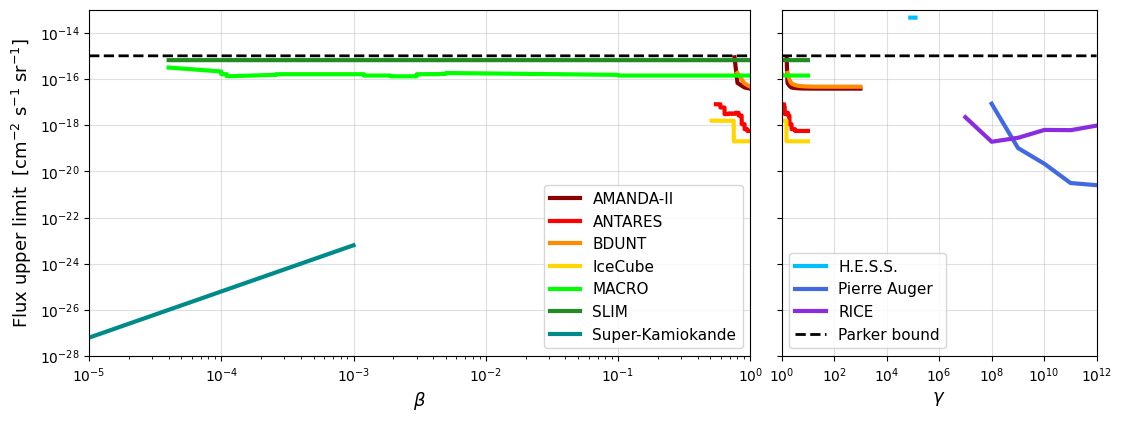

In [40]:
grid = plt.GridSpec(1, 3, wspace=0.1, hspace=0.1)

plt.figure(figsize=(13, 4.5))

plt.subplot(grid[:, :2])

plt.plot(betas, parker_bound_b, ls='--', c=clrs[0], lw=2)
plt.plot(betas, amanda_up_b, c=clrs[1], lw=3, label='AMANDA-II')
# plt.plot(betas, amanda_down_b, c=clrs[1], lw=3)
plt.plot(betas, antares_b, c=clrs[2], lw=3, label='ANTARES')
plt.plot(betas, bdunt_b, c=clrs[3], lw=3, label='BDUNT')
plt.plot(betas, icecube_b, c=clrs[4], lw=3, label='IceCube')
plt.plot(betas, macro_b, c=clrs[5], lw=3, label='MACRO')
plt.plot(betas, slim_M_b, c=clrs[6], lw=3, label='SLIM')
# plt.plot(betas, slim_m_b, c=clrs[6], lw=3)
plt.plot(betas, superk_b, c=clrs[7], lw=3, label='Super-Kamiokande')

plt.grid(alpha=0.4)
plt.xlim(np.min(betas), np.max(betas))
plt.ylim(1e-28, 1e-13)
plt.xscale('log')
plt.yscale('log')

plt.legend(fontsize=11)
plt.xlabel(r'$\beta$', fontsize=13)
plt.ylabel(r'Flux upper limit  [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=13)

plt.subplot(grid[:, 2:])

plt.plot(gammas, amanda_up_g, c=clrs[1], lw=3)
# plt.plot(gammas, amanda_down_g, c=clrs[1], lw=3)
plt.plot(gammas, antares_g, c=clrs[2], lw=3)
plt.plot(gammas, bdunt_g, c=clrs[3], lw=3)
plt.plot(gammas, icecube_g, c=clrs[4], lw=3)
plt.plot(gammas, macro_g, c=clrs[5], lw=3)
plt.plot(gammas, slim_M_g, c=clrs[6], lw=3)
# plt.plot(gammas, slim_m_g, c=clrs[6], lw=3)
plt.plot(gammas, hess_g, c=clrs[8], lw=3, label='H.E.S.S.')
plt.plot(gammas, auger_g, c=clrs[9], lw=3, label='Pierre Auger')
plt.plot(gammas, rice_g, c=clrs[10], lw=3, label='RICE')
plt.plot(gammas, parker_bound_g, ls='--', c=clrs[0], lw=2, label='Parker bound')

plt.grid(alpha=0.4)
plt.xlim(np.min(gammas), np.max(gammas))
plt.ylim(1e-28, 1e-13)
plt.xscale('log')
plt.yscale('log')

plt.legend(fontsize=11)
plt.xlabel(r'$\gamma$', fontsize=13)
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

In [41]:
# Energy loss of MMs

In [42]:
m_ec2 = 0.511 * u.MeV
e =  4.8e-10 * u.g**(1/2)*u.cm**(3/2)*u.s**(-1)
gD = 68.5 * e

n_e = 1.225e-3 * u.g*u.cm**(-3) / (14 * c.m_p) * 7
I = 88 * u.eV
k = 0.406
B = 0.248

X0 = 1.769
X1 = 4
a = 0.173
m = 3.311
hnu = 0.72 * u.eV

In [43]:
def get_delta(b):
    gam = gamma_from_beta(b)
    X = np.log10(gam * b)

    if X < X0:
        return 0

    elif X > X1:
        return 2 * np.log(gam * b) - 2 * np.log(I / hnu) - 1

    else:
        return 2 * np.log(gam * b) - 2 * np.log(I / hnu) + a * (X1 - X) ** m - 1

def bethe_bloch(b):

    gam = gamma_from_beta(b)
    delta = get_delta(b)

    bracket = np.log(2 * m_ec2 * b**2 * gam**2 / I) - 1/2 + k/2 - delta/2 - B
    ans = 4 * np.pi * n_e * gD**2 * e **2 / m_ec2 * bracket
    ans_converted = ans.to(u.MeV/u.cm)
    return ans_converted.value

In [44]:
# bees = np.linspace(0.05, beta_from_gamma(100), 1000)
bees = np.linspace(0.2, beta_from_gamma(100), 1000)
beta_blocks = np.zeros_like(bees)
for i, b in enumerate(bees):
    beta_blocks[i] = bethe_bloch(b)

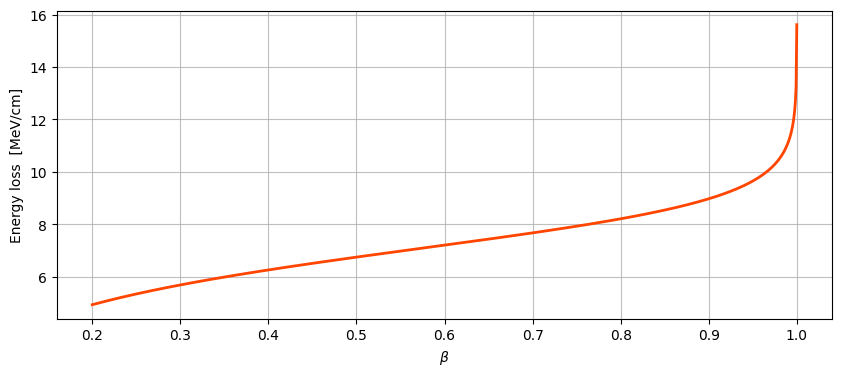

In [45]:
plt.figure(figsize=(10, 4))

plt.plot(bees, beta_blocks, lw=2, c='orangered')

plt.grid(alpha=0.8)
plt.xlabel(r'$\beta$')
plt.ylabel('Energy loss  [MeV/cm]')

plt.show()

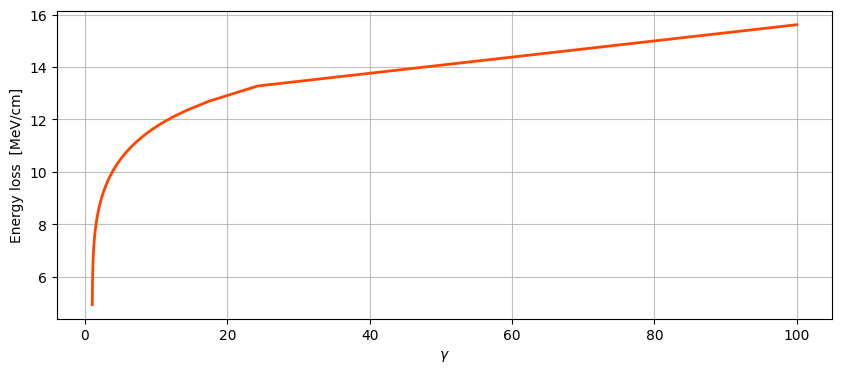

In [46]:
plt.figure(figsize=(10, 4))

plt.plot(gamma_from_beta(bees), beta_blocks, lw=2, c='orangered')

plt.grid(alpha=0.8)
plt.xlabel(r'$\gamma$')
plt.ylabel('Energy loss  [MeV/cm]')

# plt.xscale('log')
# plt.yscale('log')

plt.show()

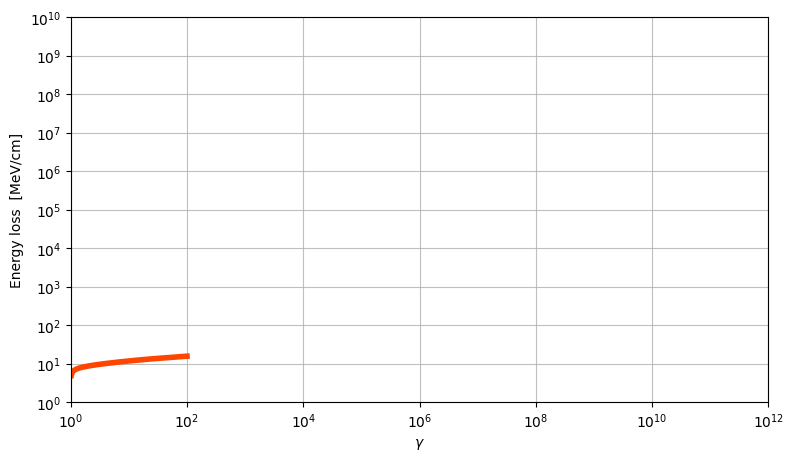

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(gamma_from_beta(bees), beta_blocks, lw=4, c='orangered')

plt.grid(alpha=0.8)
plt.xlabel(r'$\gamma$')
plt.ylabel('Energy loss  [MeV/cm]')

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e0, 1e12)
plt.ylim(1e0, 1e10)

plt.xticks(np.logspace(0, 12, 7))
plt.yticks(np.logspace(0, 10, 11))

plt.show()

In [48]:
a0 = 5.29e-9 * u.cm
vf = c.hbar / (m_ec2 / c.c**2) * (3 * np.pi**2 * n_e) ** (1/3)

In [49]:
def ahlen(b):
    bracket = np.log(2 * m_ec2 / c.c**2 * vf * a0 / c.hbar) - 1/2
    ans = 2 * np.pi * n_e * gD**2 * e**2 * b / (m_ec2 / c.c * vf)
    ans_converted = ans.to(u.MeV/u.cm)
    return ans_converted.value

In [50]:
little_bees = np.linspace(0.001, 0.01, 1000)
wa_sahlen = np.zeros_like(little_bees)
for i, b in enumerate(little_bees):
    wa_sahlen[i] = ahlen(b)

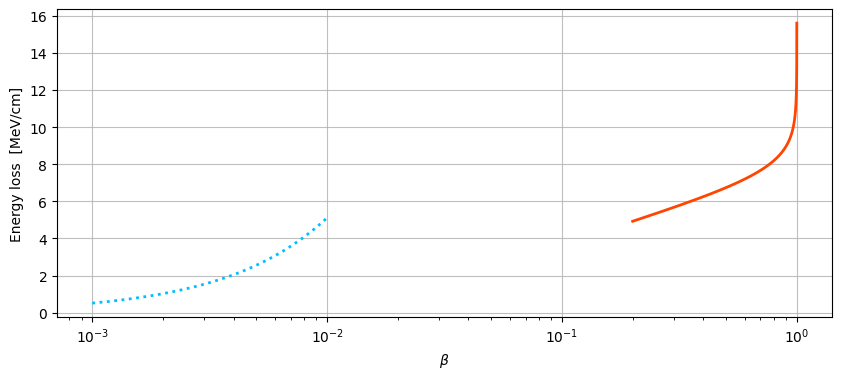

In [51]:
plt.figure(figsize=(10, 4))

plt.plot(bees, beta_blocks, lw=2, c='orangered')
plt.plot(little_bees, wa_sahlen, lw=2, c='deepskyblue', ls=':')

plt.grid(alpha=0.8)
plt.xlabel(r'$\beta$')
plt.ylabel('Energy loss  [MeV/cm]')

plt.xscale('log')

plt.show()

In [52]:
# For bash code

In [58]:
s = """
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.1wob_100MHz_850300.log      tmp_file_list_0_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.1wob_100MHz_850300.vbf.zst  tmp_file_list_0.1_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.2wob_100MHz_850300.log      tmp_file_list_0.2_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.2wob_100MHz_850300.vbf.zst  tmp_file_list_0.3_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.3wob_100MHz_850300.log      tmp_file_list_0.4_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.3wob_100MHz_850300.vbf.zst  tmp_file_list_0.5_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.4wob_100MHz_850300.log      tmp_file_list_0.6_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.4wob_100MHz_850300.vbf.zst  tmp_file_list_0.7_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.5wob_100MHz_850300.log      tmp_file_list_0.8_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.5wob_100MHz_850300.vbf.zst  tmp_file_list_0.9_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.6wob_100MHz_850300.log      tmp_file_list_1.0_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.6wob_100MHz_850300.vbf.zst  tmp_file_list_1_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.7wob_100MHz_850300.log      tmp_file_list_1.1_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.7wob_100MHz_850300.vbf.zst  tmp_file_list_1.2_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.8wob_100MHz_850300.log      tmp_file_list_1.3_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.8wob_100MHz_850300.vbf.zst  tmp_file_list_1.4_100.dat
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.9wob_100MHz_850300.log      tmp_file_list_split_0_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.9wob_100MHz_850300.vbf.zst  tmp_file_list_split_0.1_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_0wob_100MHz_850300.log        tmp_file_list_split_0.2_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_0wob_100MHz_850300.vbf.zst    tmp_file_list_split_0.3_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.1wob_100MHz_850300.log      tmp_file_list_split_0.6_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.1wob_100MHz_850300.vbf.zst  tmp_file_list_split_0.7_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.2wob_100MHz_850300.log      tmp_file_list_split_0.8_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.2wob_100MHz_850300.vbf.zst  tmp_file_list_split_0.9_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.3wob_100MHz_850300.log      tmp_file_list_split_1.0_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.3wob_100MHz_850300.vbf.zst  tmp_file_list_split_1_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.4wob_100MHz_850300.log      tmp_file_list_split_1.1_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.4wob_100MHz_850300.vbf.zst  tmp_file_list_split_1.2_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1wob_100MHz_850300.log        tmp_file_list_split_1.3_100_00
gamma_V6_CARE_std_Atmosphere61_zen10deg_1wob_100MHz_850300.vbf.zst    tmp_file_list_split_1.4_100_00
""".split()

In [59]:
new_s = ''
for name in s:
    if name.endswith('.zst'):
        new_s += name + '\n'
print(new_s)

gamma_V6_CARE_std_Atmosphere61_zen10deg_0.1wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.2wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.3wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.4wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.5wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.6wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.7wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.8wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0.9wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_0wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.1wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.2wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.3wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10deg_1.4wob_100MHz_850300.vbf.zst
gamma_V6_CARE_std_Atmosphere61_zen10

In [60]:
len(new_s.split())

15

In [61]:
new_new_s = ''

ns = ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7',
      '0.8', '0.9', '0', '1.1', '1.2', '1.3', '1.4', '1']

for i, word in enumerate(new_s.split()):
    new_new_s += '/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/' + word[:-4] \
    + ' /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w{}.root\n'.format(ns[i])

print(new_new_s)

/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/gamma_V6_CARE_std_Atmosphere61_zen10deg_0.1wob_100MHz_850300.vbf /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w0.1.root
/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/gamma_V6_CARE_std_Atmosphere61_zen10deg_0.2wob_100MHz_850300.vbf /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w0.2.root
/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/gamma_V6_CARE_std_Atmosphere61_zen10deg_0.3wob_100MHz_850300.vbf /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w0.3.root
/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/gamma_V6_CARE_std_Atmosphere61_zen10deg_0.4wob_100MHz_850300.vbf /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w0.4.root
/raid/reedbuck/lrizk/veritas/simulations/magnetic_monopole_sims/gamma_V6_CARE_std_Atmosphere61_zen10deg_0.5wob_100MHz_850300.vbf /raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/850100_w0.5.

In [62]:
# tar -cvf monopoles_Zd10.tar -T zst_list.txt 
# while read seq; do sbatch evndisp_sim_muons.sh $seq; done <muon_vbf_list.txt